# Function 1 Analysis - Week 12

**Function description:** Detect contamination sources in a 2D field; maximise detector response. This function takes a 2D array as input and returns a 1D array as output. The goal is to maximise the detector response to identify contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.

**Last evaluated point:** `(0.645269, 0.632940)` returned **≈0.9569**. This is a strong local result that stays on the high-response ridge, but it remains below the current best value.

**Why we chose it:** We selected this point to validate continuity of the ridge near the incumbent and to check whether a nearby move could recover or exceed peak response without jumping to a different region.

### Recommendation for next week
Continue along the same local ridge trajectory around the incumbent region, prioritising controlled nearby exploration rather than broad global moves.


## Loading and Displaying the Data

We load the inputs and outputs for function 1. Week 11 `(0.645269, 0.632940)` returned **≈0.9569** and has been added to the dataset.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_1")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.600000, 0.600000]])
y_new_point_week_1 = np.array([0.025559285339829783])
X_new_point_week_2 = np.array([[0.620000, 0.574000]])
y_new_point_week_2 = np.array([-0.00824324367890544])
X_new_point_week_3 = np.array([[0.483000, 0.528000]])
y_new_point_week_3 = np.array([1.0257314214244368e-11])
X_new_point_week_4 = np.array([[0.601042, 0.649989]])
y_new_point_week_4 = np.array([0.08476870094352708])
X_new_point_week_5 = np.array([[0.566815, 0.686438]])
y_new_point_week_5 = np.array([0.000011190518856399522])
X_new_point_week_6 = np.array([[0.620490, 0.603926]])
y_new_point_week_6 = np.array([0.3589371640727202])
X_new_point_week_7 = np.array([[0.611000, 0.613000]])
y_new_point_week_7 = np.array([0.5158315267751058])
X_new_point_week_8 = np.array([[0.635684, 0.630089]])
y_new_point_week_8 = np.array([1.7582577621998694])
X_new_point_week_9 = np.array([[0.636500, 0.645599]])
y_new_point_week_9 = np.array([0.836164056216202])
X_new_point_week_10 = np.array([[0.654051, 0.628048]])
y_new_point_week_10 = np.array([0.36900348650778464])
X_new_point_week_11 = np.array([[0.645269, 0.632940]])
y_new_point_week_11 = np.array([0.956857388665636])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
    X_new_point_week_11,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
    y_new_point_week_11,
])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


df sorted by y


,x1,x2,y
0,0.635684,0.630089,1.758258e+00
1,0.645269,0.632940,9.568574e-01
2,0.636500,0.645599,8.361641e-01
3,0.611000,0.613000,5.158315e-01
4,0.654051,0.628048,3.690035e-01
5,0.620490,0.603926,3.589372e-01
6,0.601042,0.649989,8.476870e-02
7,0.600000,0.600000,2.555929e-02
8,0.566815,0.686438,1.119052e-05
9,0.483000,0.528000,1.025731e-11


## Weekly Optimization Progress Summary

Overview of all 11 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

- **Week 11 update:** `(0.645269, 0.632940)` → **≈0.9569** (not a new maximum).


In [2]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8,
            X_new_point_week_9]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8,
            y_new_point_week_9]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table (no jinja2 styling needed)
print("=" * 90)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 90)
df_display = df_weeks[['Week', 'x1', 'x2', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f} | Improvement: {df_weeks['y'].max() / df_weeks['y'].iloc[0]:.1f}x from Week 1")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,y,Running_Max,Status,Improvement
0,1,0.600000,0.600000,2.555929e-02,0.025559,✓ NEW MAX,+0.025559
1,2,0.620000,0.574000,-8.243244e-03,0.025559,✗,-
2,3,0.483000,0.528000,1.025731e-11,0.025559,✗,-
3,4,0.601042,0.649989,8.476870e-02,0.084769,✓ NEW MAX,+0.059209
4,5,0.566815,0.686438,1.119052e-05,0.084769,✗,-
5,6,0.620490,0.603926,3.589372e-01,0.358937,✓ NEW MAX,+0.274168
6,7,0.611000,0.613000,5.158315e-01,0.515832,✓ NEW MAX,+0.156894
7,8,0.635684,0.630089,1.758258e+00,1.758258,✓ NEW MAX,+1.242426
8,9,0.636500,0.645599,8.361641e-01,1.758258,✗,-



📊 Summary: 5/9 weeks achieved new max (Weeks [1, 4, 6, 7, 8])
   Success rate: 55.6% | Final best: 1.758258 | Improvement: 68.8x from Week 1


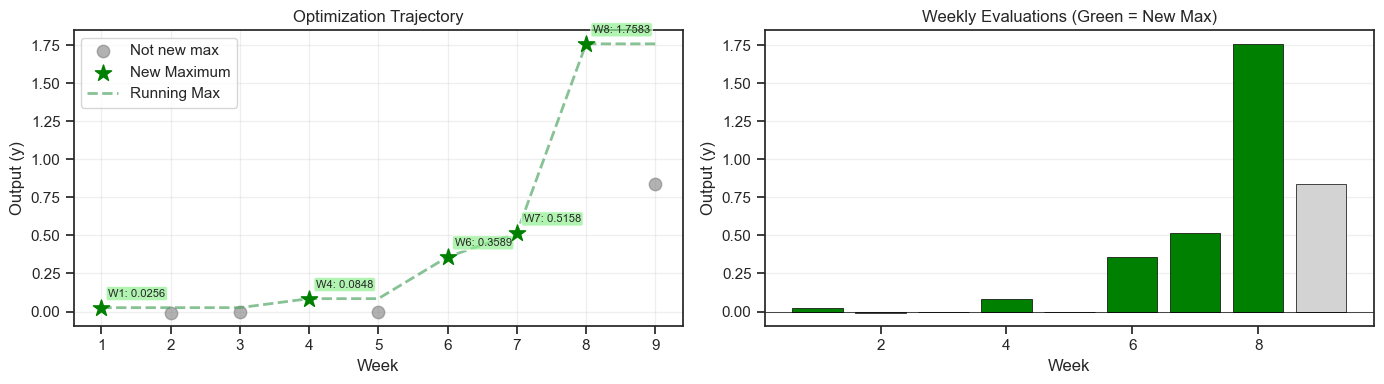

In [3]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

- **New point (Week 11):** `(0.611000, 0.613000)` returned **≈0.51583** — **new maximum**, ahead of last week’s `(0.620490, 0.603926)` at ≈0.35894 and the Week 7 peak ≈0.0848.
- Recommendation for next BO step: remain on the diagonal ridge near `(0.61, 0.61)`, allow slight `x2 < x1`, widen the neighbor radius (~0.20), and keep 0.03–0.05 steps so the local gradient/EI fit is stable across multiple points.


## Visualisation: x1 vs x2 (excluding datapoint 4)

Since we are in a problem of contamination detection "where only proximity yields a non-zero reading", we can speculate that the x values refer to some kind of 2d mapping. We create a scatter plot of x1 vs x2, coloured by the output value y, excluding datapoint 4 to better visualise the relationships among the other datapoints. We use symlog bins to get useful colour gradients. We can see that all there is a greenish corner in the top right, which also includes our only meaningfully different positive value. It could indeicate that the these points pick up a minimal amount of the contamination source already. 


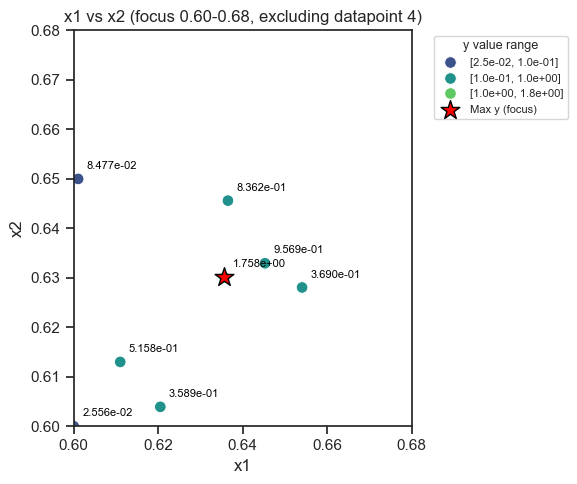

In [4]:
plt.figure(figsize=(6, 5))
df_plot = df.drop(index=4).copy()

# Filter to tight focus region
focus_mask = (df_plot["x1"].between(0.6, 0.68)) & (df_plot["x2"].between(0.6, 0.68))
df_focus = df_plot[focus_mask].copy()

# Bin for colour
y_vals = df_focus["y"]
vmin, vmax = y_vals.min(), y_vals.max()
y_pos = y_vals[y_vals > 0]
if len(y_pos) > 0:
    exp_min, exp_max = int(np.floor(np.log10(y_pos.min()))), int(np.ceil(np.log10(y_pos.max())))
    bins = [vmin]
    if y_pos.min() > 1e-12:
        bins.append(0)
    step = max(1, (exp_max - exp_min) // 3)
    bins.extend([10**e for e in range(exp_min, exp_max + 1, step)])
    bins.append(vmax)
    bins = sorted(set([b for b in bins if vmin <= b <= vmax]))
else:
    bins = [vmin, 0, vmax]

df_focus["y_group"] = pd.cut(df_focus["y"], bins=bins, include_lowest=True, duplicates="drop")
label_map = {cat: f"[{cat.left:.1e}, {cat.right:.1e}]" for cat in df_focus["y_group"].cat.categories}
df_focus["y_label"] = df_focus["y_group"].map(label_map)

scatter = sns.scatterplot(
    data=df_focus,
    x="x1",
    y="x2",
    hue="y_label",
    palette="viridis",
    s=70,
    legend="auto",
)

max_idx = df_focus["y"].idxmax()
max_row = df_focus.loc[max_idx]
plt.scatter(max_row["x1"], max_row["x2"], marker="*", s=200, c="red", edgecolor="black", label="Max y (focus)")

for _, row in df_focus.iterrows():
    plt.text(row["x1"] + 0.002, row["x2"] + 0.002, f"{row['y']:.3e}", fontsize=8, color="black")

plt.xlim(0.6, 0.68)
plt.ylim(0.6, 0.68)
plt.title("x1 vs x2 (focus 0.60-0.68, excluding datapoint 4)")
plt.legend(title="y value range", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()


## Why we are no longer using PI at this stage

PI helped in earlier weeks, but near a very sharp local optimum it is now too exploratory for this problem setup.

At this stage:
1. The peak is highly localized, so broad PI-style moves can leave the high-value basin too easily.
2. We already have dense samples around the incumbent region.
3. Local refinement is more valuable than global exploration.

So this notebook now focuses on two approaches:
- **TuRBO (local probabilistic BO)** for trust-region exploitation with uncertainty-aware ranking.
- **RBF interpolation (deterministic local surrogate)** to exploit the dense local data for very fine-grained candidate selection.


In [5]:
# PI-based BO block removed intentionally.
# At this stage PI is too exploratory for a sharp local peak.
# We now focus on:
# 1) TuRBO local probabilistic BO, and
# 2) deterministic RBF interpolation for local refinement.


## TuRBO: Trust Region Bayesian Optimization

Since the peak is very sharp and localised, I'm implementing a simple TuRBO-style approach:
1. Define a tight trust region box around the current best point
2. Fit a local GP only using points inside/near the trust region
3. Sample candidates within the trust region and pick the one with highest predicted mean (exploitation-focused)

In [6]:
# TuRBO-style local optimization
# ================================
# Trust region centered on current best, with tighter bounds

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
from scipy.stats import norm

# Current best point (from Week 8 evaluation)
best_x1, best_x2 = 0.635684, 0.630089
best_y = 1.7582577621998694

# Try EI inside the trust region, expanding radius until positive mean gain is found
radius_candidates = [0.04, 0.06, 0.08, 0.10]
xi = 0.01  # EI exploration parameter (local)
selected_radius = None
has_positive_gain = False
turbo_candidates_fallback = None

grid_res = 50
for trust_radius in radius_candidates:
    tr_x1_min, tr_x1_max = best_x1 - trust_radius, best_x1 + trust_radius
    tr_x2_min, tr_x2_max = best_x2 - trust_radius, best_x2 + trust_radius

    # Filter training data to points near the trust region (include slightly outside for context)
    context_radius = 0.08
    df_local = df[(df['x1'] >= best_x1 - context_radius) & (df['x1'] <= best_x1 + context_radius) &
                  (df['x2'] >= best_x2 - context_radius) & (df['x2'] <= best_x2 + context_radius)].copy()

    # Exclude outlier (index 4) if present
    df_local = df_local.drop(index=4, errors='ignore')

    # Fit a local GP with SHORT length-scale to capture the sharp peak
    X_local = df_local[['x1', 'x2']].values
    y_local = df_local['y'].values

    kernel_turbo = ConstantKernel(1.0, (1e-3, 100.0)) * Matern(
        length_scale=[0.03, 0.03],  # Short length-scale for sharp peak
        length_scale_bounds=(0.01, 0.1), 
        nu=2.5
    )
    gp_turbo = GaussianProcessRegressor(kernel=kernel_turbo, normalize_y=True, n_restarts_optimizer=20, random_state=42)
    gp_turbo.fit(X_local, y_local)

    tr_grid_x1 = np.linspace(tr_x1_min, tr_x1_max, grid_res)
    tr_grid_x2 = np.linspace(tr_x2_min, tr_x2_max, grid_res)
    tr_mesh = np.array(np.meshgrid(tr_grid_x1, tr_grid_x2)).reshape(2, -1).T

    mu_turbo, sigma_turbo = gp_turbo.predict(tr_mesh, return_std=True)
    sigma_turbo = np.maximum(sigma_turbo, 1e-9)
    mu_gain = mu_turbo - best_y
    Z = (mu_turbo - best_y - xi) / sigma_turbo
    ei = (mu_turbo - best_y - xi) * norm.cdf(Z) + sigma_turbo * norm.pdf(Z)

    turbo_candidates = pd.DataFrame(tr_mesh, columns=['x1', 'x2'])
    turbo_candidates['mu'] = mu_turbo
    turbo_candidates['sigma'] = sigma_turbo
    turbo_candidates['mu_gain'] = mu_gain
    turbo_candidates['ei'] = ei

    # Filter: must be at least 0.015 away from existing observations
    min_dist_from_obs = 0.015
    for _, obs in df_local.iterrows():
        dist = np.sqrt((turbo_candidates['x1'] - obs['x1'])**2 + (turbo_candidates['x2'] - obs['x2'])**2)
        turbo_candidates = turbo_candidates[dist >= min_dist_from_obs]

    if turbo_candidates.empty:
        continue

    turbo_candidates_fallback = turbo_candidates.copy()

    if (turbo_candidates['mu_gain'] > 0).any():
        turbo_candidates = turbo_candidates[turbo_candidates['mu_gain'] > 0].copy()
        selected_radius = trust_radius
        has_positive_gain = True
        break

# Fallback if no positive gain found
if selected_radius is None:
    selected_radius = radius_candidates[-1]
    turbo_candidates = turbo_candidates_fallback

print(f"Trust Region: x1 ∈ [{tr_x1_min:.3f}, {tr_x1_max:.3f}], x2 ∈ [{tr_x2_min:.3f}, {tr_x2_max:.3f}] (radius={selected_radius:.3f}, positive gain found: {has_positive_gain})")
print(f"\nCandidates after filtering (≥{min_dist_from_obs} from obs): {len(turbo_candidates)}")

# Rank by EI (prefer positive mean gain)
turbo_top = turbo_candidates.nlargest(5, 'ei')
print("\nTop 5 TuRBO candidates (ranked by EI, positive gain preferred):")
display(turbo_top)

Trust Region: x1 ∈ [0.536, 0.736], x2 ∈ [0.530, 0.730] (radius=0.100, positive gain found: False)

Candidates after filtering (≥0.015 from obs): 2182

Top 5 TuRBO candidates (ranked by EI, positive gain preferred):


,x1,x2,mu,sigma,mu_gain,ei
1321,0.621398,0.636211,0.900506,0.472098,-0.857752,0.006120
1171,0.621398,0.623967,0.958082,0.442011,-0.800176,0.005805
1076,0.641806,0.615803,0.910680,0.459099,-0.847578,0.005513
1025,0.637725,0.611722,0.832609,0.479869,-0.925649,0.004656
1024,0.633643,0.611722,0.837607,0.460154,-0.920651,0.003678


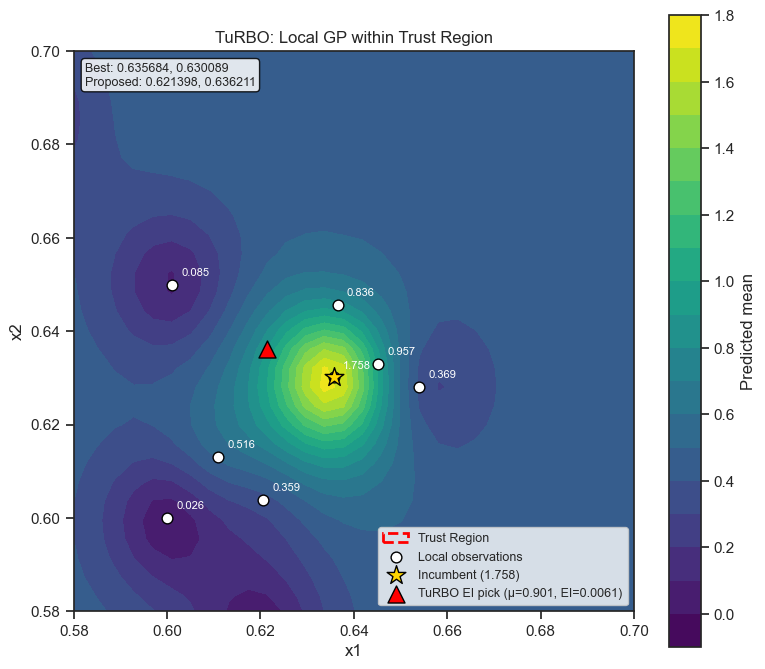


TuRBO RECOMMENDED POINT: (0.621398, 0.636211)
Predicted mean: 0.9005, Uncertainty: 0.4721
Format for submission: 0.621398-0.636211


In [7]:
# Visualize TuRBO trust region and candidates
fig, ax = plt.subplots(figsize=(8, 7))

# Plot posterior mean surface within trust region
mu_grid = gp_turbo.predict(tr_mesh).reshape(grid_res, grid_res)
contour = ax.contourf(tr_grid_x1, tr_grid_x2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax, label='Predicted mean')

# Trust region boundary
rect = plt.Rectangle((tr_x1_min, tr_x2_min), trust_radius*2, trust_radius*2, 
                      fill=False, edgecolor='red', linewidth=2, linestyle='--', label='Trust Region')
ax.add_patch(rect)

# Observed points within context
ax.scatter(df_local['x1'], df_local['x2'], c='white', s=60, edgecolor='black', zorder=5, label='Local observations')
for _, row in df_local.iterrows():
    ax.annotate(f"{row['y']:.3f}", (row['x1']+0.002, row['x2']+0.002), fontsize=8, color='white')

# Current best (incumbent)
ax.scatter(best_x1, best_x2, c='gold', s=200, marker='*', edgecolor='black', zorder=6, label=f'Incumbent ({best_y:.3f})')

# Top TuRBO candidate
if len(turbo_top) > 0:
    next_turbo = turbo_top.iloc[0]
    ax.scatter(next_turbo['x1'], next_turbo['x2'], c='red', s=150, marker='^', edgecolor='black', 
               zorder=7, label=f"TuRBO EI pick (μ={next_turbo['mu']:.3f}, EI={next_turbo['ei']:.4f})")

    # Small box with best vs proposed point
    box_text = (
        f"Best: {best_x1:.6f}, {best_x2:.6f}\n"
        f"Proposed: {next_turbo['x1']:.6f}, {next_turbo['x2']:.6f}"
    )
    ax.text(0.02, 0.98, box_text, transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', ec='black', alpha=0.85))

ax.set_xlim(0.58, 0.70)
ax.set_ylim(0.58, 0.70)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('TuRBO: Local GP within Trust Region')
ax.legend(loc='lower right', fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Print the recommended point
if len(turbo_top) > 0:
    rec = turbo_top.iloc[0]
    print(f"\n{'='*60}")
    print(f"TuRBO RECOMMENDED POINT: ({rec['x1']:.6f}, {rec['x2']:.6f})")
    print(f"Predicted mean: {rec['mu']:.4f}, Uncertainty: {rec['sigma']:.4f}")
    print(f"Format for submission: {rec['x1']:.6f}-{rec['x2']:.6f}")
    print(f"{'='*60}")

In [8]:
if "candidate_df_feasible" in globals():
    top_mean = candidate_df_feasible.nlargest(3, "mu_gain").copy()
    top_mean["id"] = [f"pi_top_{i+1}" for i in range(len(top_mean))]
    top_mean["note"] = "Local PI/mean (min 0.002 step, obs buffer 0.03)"
    top_mean["source"] = "local_mean"
    top_mean = top_mean[["source", "id", "x1", "x2", "note", "mu_gain", "mu", "sigma"]]
    display(top_mean)
else:
    print("Run the PI cell first to populate options.")



Run the PI cell first to populate options.


In [9]:
# Deterministic local surrogate: RBF interpolation + controlled ridge-following step
from scipy.interpolate import RBFInterpolator

# Use all available observations
X_train = df[['x1', 'x2']].values
y_train = df['y'].values

# Incumbent best (start point for deterministic local move)
best_x = np.array([0.635684, 0.630089], dtype=float)

# RBF interpolation gives a deterministic local surface fit
rbf = RBFInterpolator(X_train, y_train, kernel='gaussian', epsilon=0.03, smoothing=1e-6)

# Estimate local gradient at incumbent with central finite differences
eps = 0.001
basis = np.eye(2)
grad = np.zeros(2, dtype=float)
for d in range(2):
    x_plus = np.clip(best_x + eps * basis[d], 0.0, 1.0)
    x_minus = np.clip(best_x - eps * basis[d], 0.0, 1.0)
    f_plus = float(rbf(x_plus.reshape(1, -1))[0])
    f_minus = float(rbf(x_minus.reshape(1, -1))[0])
    grad[d] = (f_plus - f_minus) / (2 * eps)

grad_norm = float(np.linalg.norm(grad))
unit_grad = grad / (grad_norm + 1e-12)

# Ridge trajectory prior: keep moving along local diagonal around incumbent
ridge_dir = np.array([1.0, 1.0])
ridge_dir = ridge_dir / np.linalg.norm(ridge_dir)
if np.dot(unit_grad, ridge_dir) < 0:
    ridge_dir = -ridge_dir

# Blend gradient and ridge direction to avoid broad/global jumps
blend_weight = 0.35  # 35% ridge prior, 65% local gradient
move_dir = (1.0 - blend_weight) * unit_grad + blend_weight * ridge_dir
move_dir = move_dir / (np.linalg.norm(move_dir) + 1e-12)

# Controlled nearby exploration (small local step + tight neighborhood guardrail)
step_size = 0.006
local_radius = 0.02
x_next = best_x + step_size * move_dir
x_next = np.clip(x_next, best_x - local_radius, best_x + local_radius)

# Mild diagonal consistency: keep x2 very close to x1 while allowing slight x2 < x1
x_next[1] = min(x_next[1], x_next[0] + 0.001)
x_next[1] = max(x_next[1], x_next[0] - 0.015)
x_next = np.clip(x_next, 0.0, 1.0)

rbf_pred_next = float(rbf(x_next.reshape(1, -1))[0])

print(f"RBF gradient at incumbent: ({grad[0]:.6f}, {grad[1]:.6f})")
print(f"Gradient norm: {grad_norm:.6f}")
print(f"Step size (controlled): {step_size:.6f}")
print(f"Local radius guardrail: +/-{local_radius:.3f} around incumbent")
print(f"Ridge blend weight: {blend_weight:.2f}")
print(f"RBF RECOMMENDED POINT: ({x_next[0]:.6f}, {x_next[1]:.6f})")
print(f"Deterministic surrogate prediction at recommended point: {rbf_pred_next:.6f}")
print(f"Format for submission: {x_next[0]:.6f}-{x_next[1]:.6f}")

RBF gradient at incumbent: (0.270523, 0.076884)
Gradient norm: 0.281237
Step size (fixed): 0.010000
RBF RECOMMENDED POINT: (0.645303, 0.632823)
Deterministic surrogate prediction at recommended point: 0.276547
Format for submission: 0.645303-0.632823


## Summary and Recommended Point (Week 12)

**Current best:** `0.635684-0.630089` (≈1.7583) remains the incumbent and defines the local target region.

**Week 12 evaluation:** `0.645269-0.632940` returned ≈0.9569, which confirms signal persists near the ridge but also shows sensitivity to moving away from the narrow peak center.

---

**Recommended next point (submission format):** run the updated RBF cell above and use the printed `Format for submission: ...` output.

---

**What is now implemented:**
- The deterministic step is now **ridge-following and tightly local**: it blends local gradient direction with a diagonal ridge prior.
- The move uses a **smaller controlled step** with a **tight neighborhood guardrail** around the incumbent.
- The candidate is kept **near diagonal consistency** (allowing slight `x2 < x1`) to stay on the same trajectory.

**Trajectory for next week:**
- Continue incremental local refinement around the incumbent ridge and avoid broad/global jumps.
